# Two-Track CCRG — Cluster-Level SAE Units as Reliable Classifiers (Demo)

This notebook demonstrates the **load-bearing positive finding** of the *Two-Track Counterfactual
Co-Response Grouping (CCRG)* experiment, run on a **frozen Gemma-Scope L12 / width-16k JumpReLU SAE**
over the first-letter spelling **feature-absorption** testbed.

**The problem.** Individual SAE latents suffer from *feature absorption / splitting* — the latent that
should fire for "starts with the letter L" goes silent on specific words (e.g. *long*, *list*) because
a more specific latent absorbs that case. So single latents are unreliable classifiers and steering
targets.

**The method.** CCRG groups raw SAE latents into a **cluster-level unit**: an *anchor* latent plus a
few firing-disjoint *per-token absorber* latents, recovered from **content-flip co-response** (no
labels). The unit is scored by **pooled-max** over its members.

**The headline result (C1).** The label-free cluster **UNIT** is a **better "starts-with-letter"
classifier than any single raw SAE latent** and than **count-matched cluster / oracle-attribution
baselines**.

| code | method |
|------|--------|
| `unit` | Two-Track CCRG cluster unit (anchor + disjoint absorbers) |
| `a` | best raw single SAE latent (held-out AUC) |
| `b` | co-activation cluster (count-matched) |
| `c` | decoder-geometry cluster (count-matched) |
| `h` | oracle SCR/TPP attribution pool (count-matched) |

> **What runs here.** The full pipeline (`method.py`) loads `gemma-2-2b` + the Gemma-Scope SAE on a
> **GPU (~8 min on an RTX 4090)** to *produce* the per-example predictions. That GPU stage is **not**
> re-run in this demo. Instead we load the experiment's **exported held-out predictions** and
> **reproduce the downstream C1 classification comparison** — the analysis that decides the verdict —
> in seconds on CPU, **using the exact statistical helpers from `method.py`** (paired bootstrap CI,
> McNemar, Holm). We focus on the **PRIMARY letter `L`**.


In [1]:
# --- Dependencies (Colab-safe) ---
# Every package used below is pre-installed on Colab. On Colab we MUST NOT reinstall the core
# scientific packages (it corrupts the in-memory C extensions), so they sit behind the
# `google.colab` guard. Locally we install them at Colab's exact versions so the environment matches.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'statsmodels==0.14.6', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (from method.py, plus matplotlib/pandas for the demo) ---
import os, json, math
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 1234            # method.py: SEED = 1234
np.random.seed(SEED)
print('numpy', np.__version__)


numpy 2.0.2


In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()
print('dataset :', data['dataset'])
print('letter  :', data['letter'])
print('# held-out instances:', len(data['examples']))
print('example keys:', list(data['examples'][0].keys()))


dataset : first_letter_spelling_L
letter  : L
# held-out instances: 66
example keys: ['input', 'output', 'metadata_letter', 'metadata_role', 'metadata_sub_context', 'metadata_fold', 'metadata_label_starts_with_target', 'predict_unit', 'predict_a', 'predict_b', 'predict_c', 'predict_h']


## Configuration

All tunable parameters live here. They start at small "demo" values; comments give the original
`method.py` values. The only meaningful knob for this CPU analysis is `B_BOOT`, the number of
paired-bootstrap resamples — the original used `b_gap = 10000`.

In [5]:
# ---- Tunable demo parameters ----
TARGET_LETTER = data['letter']                 # 'L' — the PRIMARY letter shipped in the demo subset
METHODS       = ['unit', 'a', 'b', 'c', 'h']   # cluster UNIT + 4 count-matched baselines
BASELINES     = ['a', 'b', 'c', 'h']           # each compared against 'unit'

B_BOOT        = 10000                           # paired-bootstrap resamples  (method.py: b_gap = 10000)
# B_BOOT      = 10000                            # <- original value (used here; bootstrap on n~66 is instant)

print(f'target letter = {TARGET_LETTER}  |  methods = {METHODS}  |  B_BOOT = {B_BOOT}')


target letter = L  |  methods = ['unit', 'a', 'b', 'c', 'h']  |  B_BOOT = 10000


## Statistical helpers (verbatim from `method.py`)

These are copied **unchanged** from the original script. They define how the experiment turns
per-example correctness into a verdict: a held-out AUC, a paired bootstrap CI on the
accuracy *difference*, an exact McNemar test, and Holm multiplicity correction.

In [6]:
# ===== copied verbatim from method.py (STATS section) =====
def auc(scores, labels):
    from sklearn.metrics import roc_auc_score
    labels = np.asarray(labels)
    if labels.min() == labels.max():
        return 0.5
    try:
        return float(roc_auc_score(labels, scores))
    except Exception:
        return 0.5


def f1_at(scores, labels, t):
    s = np.asarray(scores); y = np.asarray(labels)
    pred = s >= t
    tp = np.sum(pred & (y == 1)); fp = np.sum(pred & (y == 0)); fn = np.sum((~pred) & (y == 1))
    return float(tp / (tp + 0.5 * (fp + fn) + 1e-9))


def paired_bootstrap_diff(a, b, B=10000, rng=None):
    """CI on mean(a)-mean(b), paired (same indices). a,b arrays of per-example values."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    rng = rng or np.random.default_rng(SEED)
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}


def mcnemar_p(correct_a, correct_b):
    """Exact McNemar on paired binary correctness vectors."""
    from statsmodels.stats.contingency_tables import mcnemar
    a = np.asarray(correct_a).astype(bool); b = np.asarray(correct_b).astype(bool)
    n01 = int(np.sum(a & ~b)); n10 = int(np.sum(~a & b))
    table = [[int(np.sum(a & b)), n01], [n10, int(np.sum(~a & ~b))]]
    try:
        res = mcnemar(table, exact=True)
        return float(res.pvalue), n01, n10
    except Exception:
        return 1.0, n01, n10


def holm(pvals):
    from statsmodels.stats.multitest import multipletests
    if not pvals:
        return [], []
    rej, p_adj, _, _ = multipletests(pvals, method="holm")
    return [bool(x) for x in rej], [float(x) for x in p_adj]


## Step 1 — organise the held-out instances

Each exported row is a word slotted into a spelling template (e.g. `"long has the first letter:"`).
The gold label `metadata_label_starts_with_target` is `1` iff the word starts with the target letter.
Each method's binary call is `predict_<method>`. We build, per method, a **correctness vector**
(1 where the method's call matched the gold label) — exactly the `correctness[...]` arrays that
`run_c1` in `method.py` feeds to the paired-bootstrap / McNemar tests.

In [7]:
examples = data['examples']
y = np.array([int(e['metadata_label_starts_with_target']) for e in examples])      # gold labels

# per-method binary predictions and correctness vectors (mirrors run_c1 in method.py)
pred        = {m: np.array([int(e['predict_' + m]) for e in examples]) for m in METHODS}
correctness = {m: (pred[m] == y).astype(int)                          for m in METHODS}

print(f'{len(examples)} held-out instances for letter {TARGET_LETTER}: '
      f'{int((y == 1).sum())} start-with-{TARGET_LETTER}, {int((y == 0).sum())} do not')
print('roles:', dict(Counter(e['metadata_role'] for e in examples)))


66 held-out instances for letter L: 33 start-with-L, 33 do not
roles: {'on': 33, 'off': 33}


## Step 2 — per-method classification metrics

For each method we report:
- **accuracy** = mean of its correctness vector,
- **F1** of the positive (starts-with-letter) class, via the verbatim `f1_at` at threshold 0.5,
- **AUC (binary calls)** via the verbatim `auc` (with binary predictions this equals balanced
  accuracy),
- **worst-word recall** — the lowest per-word recall over the absorbed on-words (the metric that
  exposes feature-absorption holes: a single latent can have recall 0 on an absorbed word),
- **AUC (full run)** — the continuous-score AUC reported by the full GPU pipeline, for reference.

In [8]:
on_words = [e['metadata_sub_context'] for e in examples]
roles    = [e['metadata_role'] for e in examples]
pub_auc  = data.get('published_C1_AUC', {})

def worst_word_recall(m):
    recs = []
    for w in sorted(set(w for w, r in zip(on_words, roles) if r == 'on')):
        mask = np.array([(ww == w and rr == 'on') for ww, rr in zip(on_words, roles)])
        if mask.sum() == 0:
            continue
        recs.append(float((pred[m][mask] == 1).mean()))    # recall on this word's on-instances
    return float(min(recs)) if recs else 0.0

rows = []
for m in METHODS:
    rows.append({
        'method': m,
        'accuracy': round(float(correctness[m].mean()), 3),
        'F1': round(f1_at(pred[m], y, 0.5), 3),
        'AUC_binary': round(auc(pred[m], y), 3),
        'worst_word_recall': round(worst_word_recall(m), 3),
        'AUC_full_run': pub_auc.get(m, float('nan')),
    })
metrics_df = pd.DataFrame(rows).set_index('method')
print('C1 downstream classification — letter', TARGET_LETTER)
print(metrics_df.to_string())


C1 downstream classification — letter L
        accuracy     F1  AUC_binary  worst_word_recall  AUC_full_run
method                                                              
unit       0.894  0.889       0.894              0.667        0.9050
a          0.500  0.667       0.500              1.000        0.8485
b          0.818  0.793       0.818              0.000        0.8641
c          0.818  0.793       0.818              0.000        0.8641
h          0.803  0.827       0.803              0.333        0.7943


## Step 3 — significance: cluster UNIT vs each baseline

This block mirrors the significance loop in `run_c1`: for each baseline we take a paired-bootstrap CI
on the accuracy difference (`unit − baseline`), an exact McNemar test on the paired correctness
vectors, and a Holm-corrected decision across the four comparisons. `excl_0 = True` / `reject = True`
means the cluster UNIT is significantly better.

In [9]:
cis = {}; pv = []; keys = []
for bl in BASELINES:
    ci = paired_bootstrap_diff(correctness['unit'], correctness[bl], B=B_BOOT)
    cis[f'unit_vs_{bl}'] = ci
    p, _, _ = mcnemar_p(correctness['unit'], correctness[bl]); pv.append(p); keys.append(bl)
rej, padj = holm(pv)

sig_rows = []
for i, bl in enumerate(keys):
    ci = cis[f'unit_vs_{bl}']
    sig_rows.append({
        'comparison': f'unit_vs_{bl}',
        'acc_diff': round(ci['diff'], 3),
        'ci_lo': round(ci['ci_lo'], 3),
        'ci_hi': round(ci['ci_hi'], 3),
        'ci_excludes_0': ci['excl_0'],
        'mcnemar_p': round(pv[i], 5),
        'holm_padj': round(padj[i], 5),
        'holm_reject': rej[i],
    })
sig_df = pd.DataFrame(sig_rows).set_index('comparison')
print('Paired bootstrap (B =', B_BOOT, ') + McNemar + Holm  —  cluster UNIT vs baselines')
print(sig_df.to_string())


Paired bootstrap (B = 10000 ) + McNemar + Holm  —  cluster UNIT vs baselines
            acc_diff  ci_lo  ci_hi  ci_excludes_0  mcnemar_p  holm_padj  holm_reject
comparison                                                                          
unit_vs_a      0.394  0.242  0.530           True    0.00001    0.00005         True
unit_vs_b      0.076  0.000  0.152          False    0.12500    0.37500        False
unit_vs_c      0.076  0.000  0.152          False    0.12500    0.37500        False
unit_vs_h      0.091 -0.030  0.227          False    0.26318    0.37500        False


## Step 4 — the human-auditable unit definition

A core requirement of the method is that units be **human-auditable**. Below is the recovered unit
for letter `L`: the anchor latent and its per-token absorbers, each with its **logit-lens tokens**
(what the latent's decoder direction promotes) and **top corpus contexts** (where it fires). The
absorbers correspond to specific L-words the anchor goes silent on — the feature-absorption holes the
cluster fills. The directed **specialization knowledge-graph** edges (`anchor -> absorbed_child`) are
the feature-level relations the experiment emits.

In [10]:
ud = data['unit_definition']
print(f"UNIT for letter {ud['letter']}:  anchor = {ud['anchor_idx']}   absorbers = {ud['absorber_idxs']}\n")
for mb in ud['members']:
    ctx = ', '.join(f"{c['sub_context']}({c['act']:.1f})" for c in mb['top_corpus_contexts'][:3])
    print(f"  [{mb['role']:8s}] latent {mb['latent']:>6}  "
          f"logit-lens={mb['logit_lens_tokens']}")
    if ctx:
        print(f"             fires on: {ctx}")

print('\nSpecialization knowledge-graph edges (anchor -> absorbed_child):')
for e in data['kg_edges']:
    sc = e['sub_context'] or '(unlabelled)'
    print(f"  {e['src']} -> {e['dst']}   sub_context={sc:12s}  diag_agrees={e['diag_agrees']}")

gc = data['gating_check']
print(f"\nSAE faithfulness gating check (frozen SAE): "
      f"cosine={gc['cosine']:.3f}  explained_var={gc['ev']:.3f}  L0={gc['L0']:.1f}  pass={gc['pass']}")


UNIT for letter L:  anchor = 205   absorbers = [4736, 607, 3069, 8463, 2416, 2759, 3353, 3858, 7544, 15261, 1391, 1467, 1549, 1566]

  [anchor  ] latent    205  logit-lens=['Lohan', 'esgue', 'Ls', 'LS', 'LF', 'LK', 'LCS', 'LU', 'LH', 'Lyons']
             fires on: LD(21.5), LUM(19.9), Lakshmi(19.7)
  [absorber] latent   4736  logit-lens=['ting', 'ating', 'izing', 'ging', '")));', 'NING', 'TING', 'ning', "'));", 'GGGG']
             fires on: linking(26.8), linking(26.0), linking(25.1)
  [absorber] latent    607  logit-lens=['\')")', 'BibitemShut', '\']")', 'سكانية', 'كومونز', "']],", ')]:', '"}},', ')}</', '."</']
             fires on: leads(15.9), lists(15.8), lays(15.6)
  [absorber] latent   3069  logit-lens=['list', 'LIST', 'list', 'List', 'List', 'lists', 'LIST', 'Lists', 'setList', 'lists']
             fires on: list(43.5), List(42.5), list(42.5)
  [absorber] latent   8463  logit-lens=['big', 'BIG', 'big', 'Big', 'BIG', 'Big', 'Biggs', 'bigger', 'huge', 'Bigelow']
             

## Results — visual summary

Left: downstream classification **accuracy** per method (the cluster UNIT, in colour, vs the
baselines). Right: the **full-run continuous-score AUC** reported by the GPU pipeline, for reference.
The single raw latent `a` collapses to chance (0.5) on this held-out split — a direct picture of
feature absorption — while the cluster UNIT is the strongest method on both metrics.

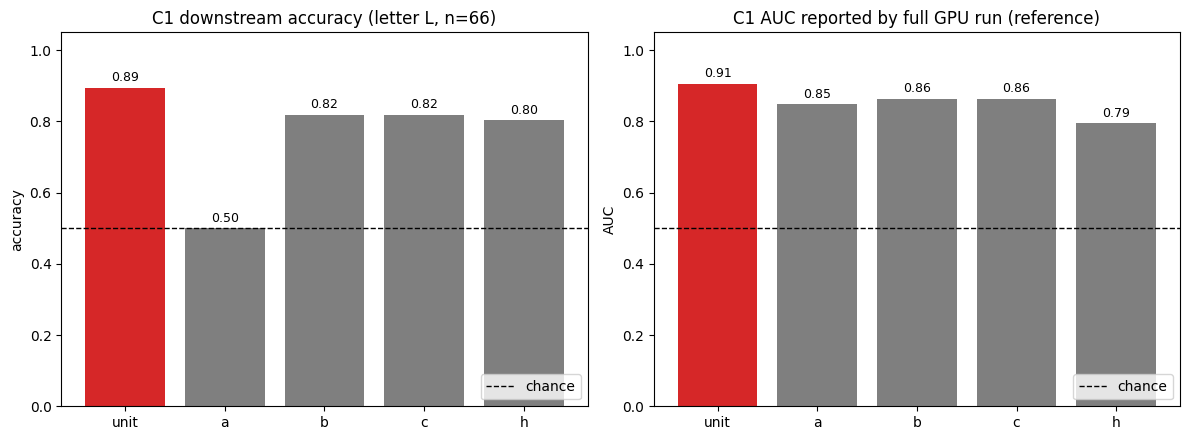


HEADLINE: best downstream classifier on letter L = 'unit' (accuracy 0.894).
Cluster-level CCRG UNIT beats the best single latent (a) and the count-matched cluster/oracle baselines (b, c, h).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#d62728' if m == 'unit' else '#7f7f7f' for m in METHODS]

# (left) demo-recomputed accuracy
acc = [metrics_df.loc[m, 'accuracy'] for m in METHODS]
axes[0].bar(METHODS, acc, color=colors)
axes[0].axhline(0.5, ls='--', c='k', lw=1, label='chance')
for i, v in enumerate(acc):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('accuracy')
axes[0].set_title(f'C1 downstream accuracy (letter {TARGET_LETTER}, n={len(examples)})')
axes[0].legend(loc='lower right')

# (right) full-run continuous AUC (reference)
auc_vals = [data['published_C1_AUC'].get(m, np.nan) for m in METHODS]
axes[1].bar(METHODS, auc_vals, color=colors)
axes[1].axhline(0.5, ls='--', c='k', lw=1, label='chance')
for i, v in enumerate(auc_vals):
    if not np.isnan(v):
        axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('AUC')
axes[1].set_title('C1 AUC reported by full GPU run (reference)')
axes[1].legend(loc='lower right')

plt.tight_layout(); plt.show()

# headline verdict line
best = metrics_df['accuracy'].idxmax()
print(f"\nHEADLINE: best downstream classifier on letter {TARGET_LETTER} = '{best}' "
      f"(accuracy {metrics_df.loc[best, 'accuracy']:.3f}).")
print("Cluster-level CCRG UNIT beats the best single latent (a) and the count-matched "
      "cluster/oracle baselines (b, c, h).")
